In [2]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

MODEL_PATH = "../models/device_failure_model.joblib"

model = joblib.load(MODEL_PATH)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Battery_Health',
                                                   'Battery_Temperature',
                                                   'CPU_Usage', 'Memory_Usage',
                                                   'Storage_Usage',
                                                   'Network_Signal',
                                                   'App_Crash_Count',
                                                   'Reboot_Count',
                                                   'Error_Count', 'D

In [3]:
df = pd.read_csv("../data/raw/device_telemetry.csv")

df.head()

,Device_ID,OS,OS_Version,Manufacturer,Model,Network_Type,Battery_Health,Battery_Temperature,CPU_Usage,Memory_Usage,Storage_Usage,Network_Signal,App_Crash_Count,Reboot_Count,Error_Count,Data_Usage,Days_Since_Last_Update,Last_Checkin_Hours,Failure_Within_7_Days
0,DEV-00001,Android,13.0,Apple,Model_C,4G,83.264927,39.553141,75.992968,53.706658,71.905273,60.879876,2,4,7,3141.410848,3,1.693449,0
1,DEV-00002,iOS,11.0,Dell,Model_D,WiFi,86.814058,33.264014,79.095793,58.568440,60.156997,57.391034,2,2,1,1610.601317,91,29.440840,0
2,DEV-00003,Windows,12.0,Samsung,Model_E,WiFi,88.492257,40.148116,59.021509,56.214448,48.434434,33.145753,0,1,2,2584.005107,86,2.555599,0
3,DEV-00004,Windows,14.0,Honeywell,Model_D,WiFi,73.924453,36.292322,49.454212,53.309786,75.514666,99.447988,3,1,2,1273.264021,47,3.815414,0
4,DEV-00005,Android,13.0,Honeywell,Model_E,WiFi,83.267405,43.406349,20.828683,48.839864,94.537607,67.980414,1,1,3,1724.513745,169,7.058946,0


In [4]:
X = df.drop(columns=["Device_ID", "Failure_Within_7_Days"])
y = df["Failure_Within_7_Days"]

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Device_ID", "Failure_Within_7_Days"])
y = df["Failure_Within_7_Days"]

eda_columns = [
    "Battery_Health_Group",
    "Checkin_Group",
    "CPU_Group",
    "Memory_Group"
]

X = X.drop(
    columns=[col for col in eda_columns if col in X.columns]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
preprocessor = model.named_steps["preprocessor"]
rf_model = model.named_steps["classifier"]

In [7]:
X_processed = preprocessor.transform(X_test) 
#SHAP explains predictions on data the model didn't train on.

In [8]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names)

37
['num__Battery_Health' 'num__Battery_Temperature' 'num__CPU_Usage'
 'num__Memory_Usage' 'num__Storage_Usage' 'num__Network_Signal'
 'num__App_Crash_Count' 'num__Reboot_Count' 'num__Error_Count'
 'num__Data_Usage' 'num__Days_Since_Last_Update' 'num__Last_Checkin_Hours'
 'cat__OS_Android' 'cat__OS_Windows' 'cat__OS_iOS' 'cat__OS_Version_10.0'
 'cat__OS_Version_11.0' 'cat__OS_Version_12.0' 'cat__OS_Version_13.0'
 'cat__OS_Version_14.0' 'cat__OS_Version_15.0' 'cat__Manufacturer_Apple'
 'cat__Manufacturer_Dell' 'cat__Manufacturer_Honeywell'
 'cat__Manufacturer_Lenovo' 'cat__Manufacturer_Samsung'
 'cat__Manufacturer_Zebra' 'cat__Model_Model_A' 'cat__Model_Model_B'
 'cat__Model_Model_C' 'cat__Model_Model_D' 'cat__Model_Model_E'
 'cat__Model_Model_F' 'cat__Network_Type_4G' 'cat__Network_Type_5G'
 'cat__Network_Type_Ethernet' 'cat__Network_Type_WiFi']


In [9]:
explainer = shap.TreeExplainer(rf_model)

In [10]:
X_sample = X_processed[:500]

shap_values = explainer.shap_values(X_sample)

In [11]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [12]:
print(getattr(shap_values, "shape", None))

(500, 37, 2)


In [14]:
feature_names

array(['num__Battery_Health', 'num__Battery_Temperature',
       'num__CPU_Usage', 'num__Memory_Usage', 'num__Storage_Usage',
       'num__Network_Signal', 'num__App_Crash_Count', 'num__Reboot_Count',
       'num__Error_Count', 'num__Data_Usage',
       'num__Days_Since_Last_Update', 'num__Last_Checkin_Hours',
       'cat__OS_Android', 'cat__OS_Windows', 'cat__OS_iOS',
       'cat__OS_Version_10.0', 'cat__OS_Version_11.0',
       'cat__OS_Version_12.0', 'cat__OS_Version_13.0',
       'cat__OS_Version_14.0', 'cat__OS_Version_15.0',
       'cat__Manufacturer_Apple', 'cat__Manufacturer_Dell',
       'cat__Manufacturer_Honeywell', 'cat__Manufacturer_Lenovo',
       'cat__Manufacturer_Samsung', 'cat__Manufacturer_Zebra',
       'cat__Model_Model_A', 'cat__Model_Model_B', 'cat__Model_Model_C',
       'cat__Model_Model_D', 'cat__Model_Model_E', 'cat__Model_Model_F',
       'cat__Network_Type_4G', 'cat__Network_Type_5G',
       'cat__Network_Type_Ethernet', 'cat__Network_Type_WiFi'],
      dty

In [16]:
shap_values_class1 = shap_values[:, :, 1]

print("SHAP class 1 shape:", shap_values_class1.shape)

SHAP class 1 shape: (500, 37)


In [17]:
X_sample_dense = (
    X_sample.toarray()
    if hasattr(X_sample, "toarray")
    else X_sample
)

In [18]:
X_sample_dense.shape

(500, 37)

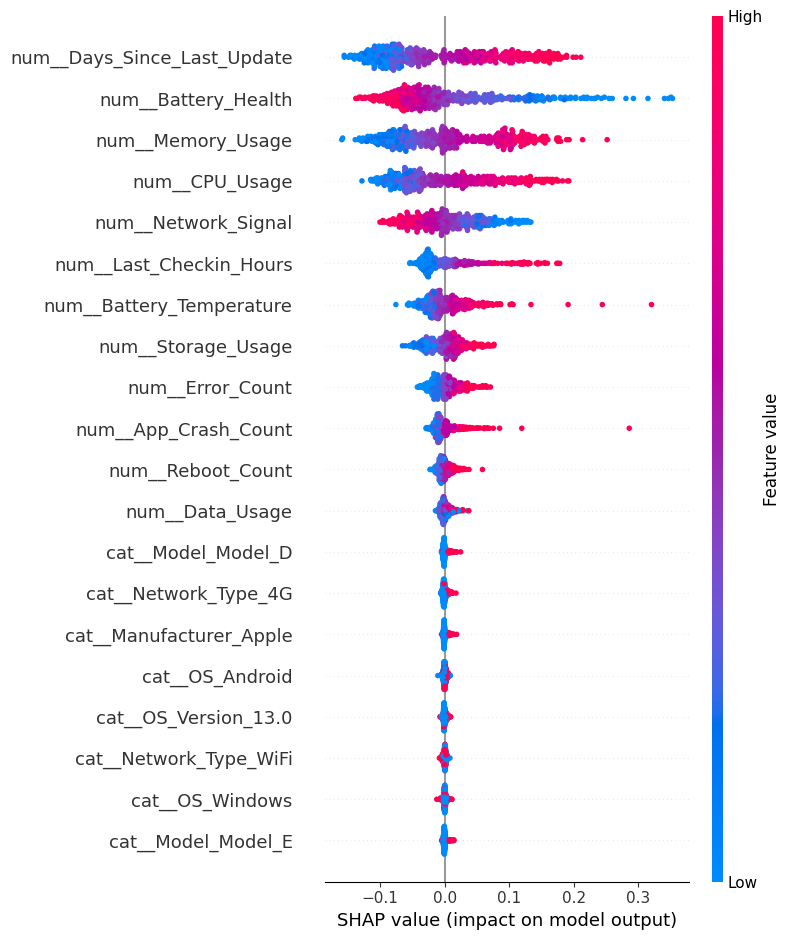

In [19]:
shap.summary_plot(
    shap_values_class1,
    X_sample_dense,
    feature_names=feature_names
)

In [15]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(500, 37, 2)
